In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import fmcg
from fmcg.configs.measurement_config_2024_07_05 import r_sensors, axis_mask
from fmcg.pipeline.preprocessing import preprocess
from fmcg.utils.synthetic_data_generation import generate_synthetic_fmcg_recording
from fmcg.utils.field_metrics import compute_named_field_metrics
from fmcg.fitting.field_model import ForwardModel
from fmcg.fitting.inverse_solver import InverseSolver
from fmcg.ica.ica_component_labeler import ICAComponentLabeler
from fmcg.ica.ics import ics
from fmcg.spatial_filtering.spatial_filters import SpatialFilter
from fmcg.utils.plotting.plot_utils import plot_single_channel

logging.basicConfig(level=logging.ERROR, format='%(message)s', force=True)

## Load Noise Recording

Realistic noise from a real empty-device measurement is added to the synthetic field, making the benchmark more representative than Gaussian noise.

In [3]:
from fmcg.utils.data import load_structured_patient_data_and_noise
_, _, fs_noise, noise_dict_raw = load_structured_patient_data_and_noise(
    ds_path=os.path.dirname(os.path.abspath('.')) + "/data",
    patient="P097",
    series="S07",
    sig_group_names="R004",
    noise_group_names="R004",
)

noise_data_arr = np.stack(list(noise_dict_raw.values()), axis=1)
noise_kwargs   = dict(noise_type='recording', noise_data=noise_data_arr, fs_noise=fs_noise)
print(f"Loaded noise recording: {noise_data_arr.shape[0]} samples at {fs_noise} Hz")

Loaded noise recording: 57278 samples at 1000 Hz


## Generate Synthetic fMCG Recording

In [4]:
data = generate_synthetic_fmcg_recording(
    r_sensors=r_sensors,
    axis_mask=axis_mask,
    snr_db=0,                              # 0 dB: signal power == noise power
    sampto=60,
    decimation_factor=1,                   # VCG source is 1000 Hz; keep at 1000 Hz
    seed=42,
    fetal_moment_amplitude_nAm2=25,        # nA·m² (reference baseline)
    maternal_moment_amplitude_nAm2=4000,   # nA·m² (reference baseline)
    gaussian_noise_fraction=0.05,
    return_sources=True,
    return_clean=True,
    **noise_kwargs,
)

field_measured = data['field_measured']  # (T, N, 3) noisy combined field [pT]
field_clean    = data['field_clean']     # (T, N, 3) noiseless combined field [pT]
field_fetal    = data['field_fetal']     # (T, N, 3) ground-truth fetal source [pT]
field_maternal = data['field_maternal']  # (T, N, 3) ground-truth maternal source [pT]
m_true = data['m_true']  # (T, 2, 3) true dipole moments [µA·m²]
r_true = data['r_true']  # (T, 2, 3) true dipole positions [m]
time   = data['time']
fs     = data['fs']

print(f"Recording: {field_measured.shape[0]/fs:.0f}s at {fs} Hz, {int(axis_mask.sum())} valid channels")

Sampling physiological positions...
  Fetal position: [-0.5697819 -8.1146256  0.4873102] cm
  Maternal position: [ 2.28200657 -4.78601251 36.3787841 ] cm
  Separation: 36.2 cm
Loading VCG data...
  Fetal: patient104/s0306lre
  Maternal: patient104/s0306lre
  Moment amplitude (with random variation):
    Fetal: 0.024 μA·m² = 24.4 nA·m² (peak magnitude: 2.351 mV, scaling: 0.0104)
    Maternal: 4.574 μA·m² = 4573.8 nA·m² (peak magnitude: 2.351 mV, scaling: 1.9457)
    Ratio: 187.5×
  Fetal rotation [deg]: [  71.05 -146.1   171.22]
  Maternal rotation [deg]: [  94.01  102.98 -133.88]
Computing forward model on cpu...
Adding noise (SNR=0 dB, type=recording)...
Signal power: 1.260664939880371, Noise power: 120.70086909276088
Added Gaussian noise: fraction=0.05, ref_p99=6.0952e+00, std=3.0476e-01
✅ Generated synthetic recording: 60000 samples (60.0 s) at 1000.0 Hz
Recording: 60s at 1000.0 Hz, 33 valid channels


## Ground Truth Source Fields

Inspect the clean per-source fields before any preprocessing is applied.

GT fetal peak:    4.8 pT
GT maternal peak: 15.9 pT
GT clean peak:    17.3 pT


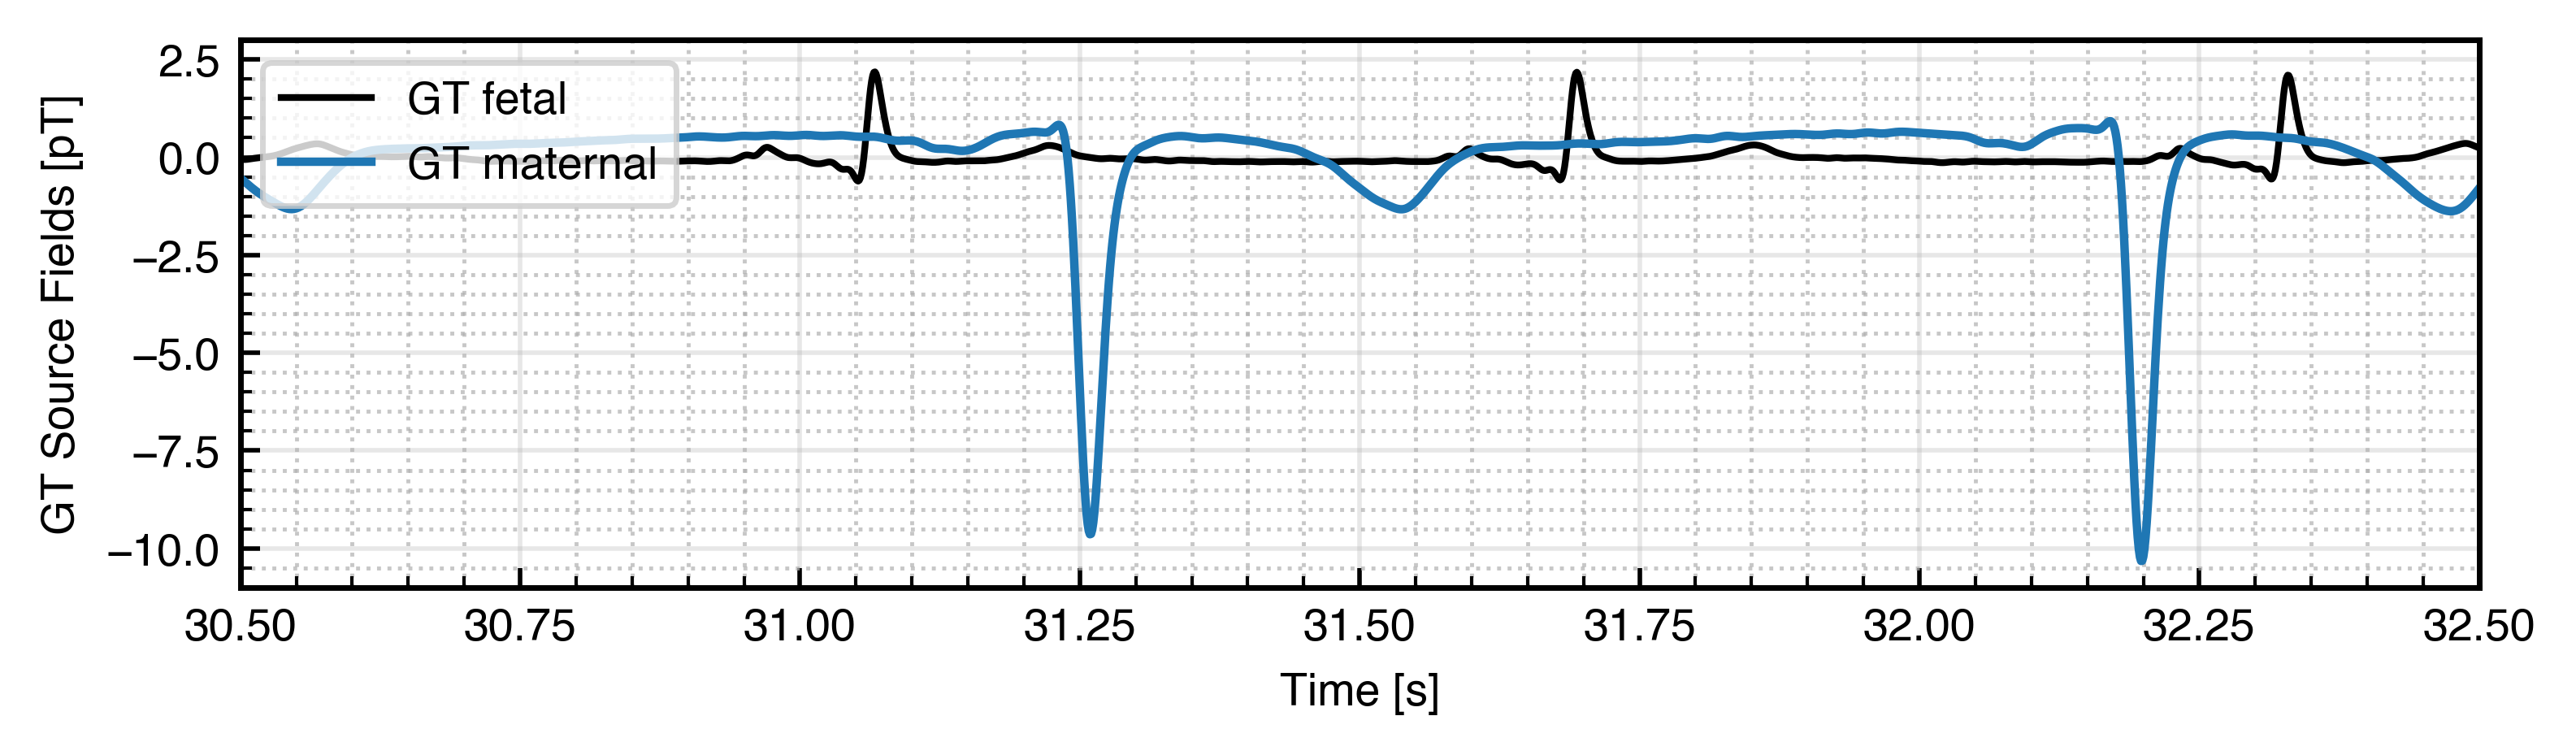

In [5]:
# GT fields in physical domain, valid channels only
gt_fetal    = field_fetal[:, axis_mask == 1]    # (T, C) [pT]
gt_maternal = field_maternal[:, axis_mask == 1] # (T, C) [pT]
gt_clean    = field_clean[:, axis_mask == 1]    # (T, C) [pT] — noiseless combined

print(f"GT fetal peak:    {np.nanmax(np.abs(gt_fetal)):.1f} pT")
print(f"GT maternal peak: {np.nanmax(np.abs(gt_maternal)):.1f} pT")
print(f"GT clean peak:    {np.nanmax(np.abs(gt_clean)):.1f} pT")

fig = plot_single_channel(
    gt_fetal,
    [gt_maternal],
    channel=10, # one exemplary channel is shown
    time=time,
    xlim=(30.5, 32.5),
    method_labels=['GT maternal'],
    gt_label='GT fetal',
    ylabel='GT Source Fields [pT]',
)

## Noisy Observation

`field_measured = field_clean + recording_noise` at `SNR_DB` dB. Comparing a single channel of the noiseless combined field against the noisy measurement shows the noise floor.

Measured peak: 170.4 pT


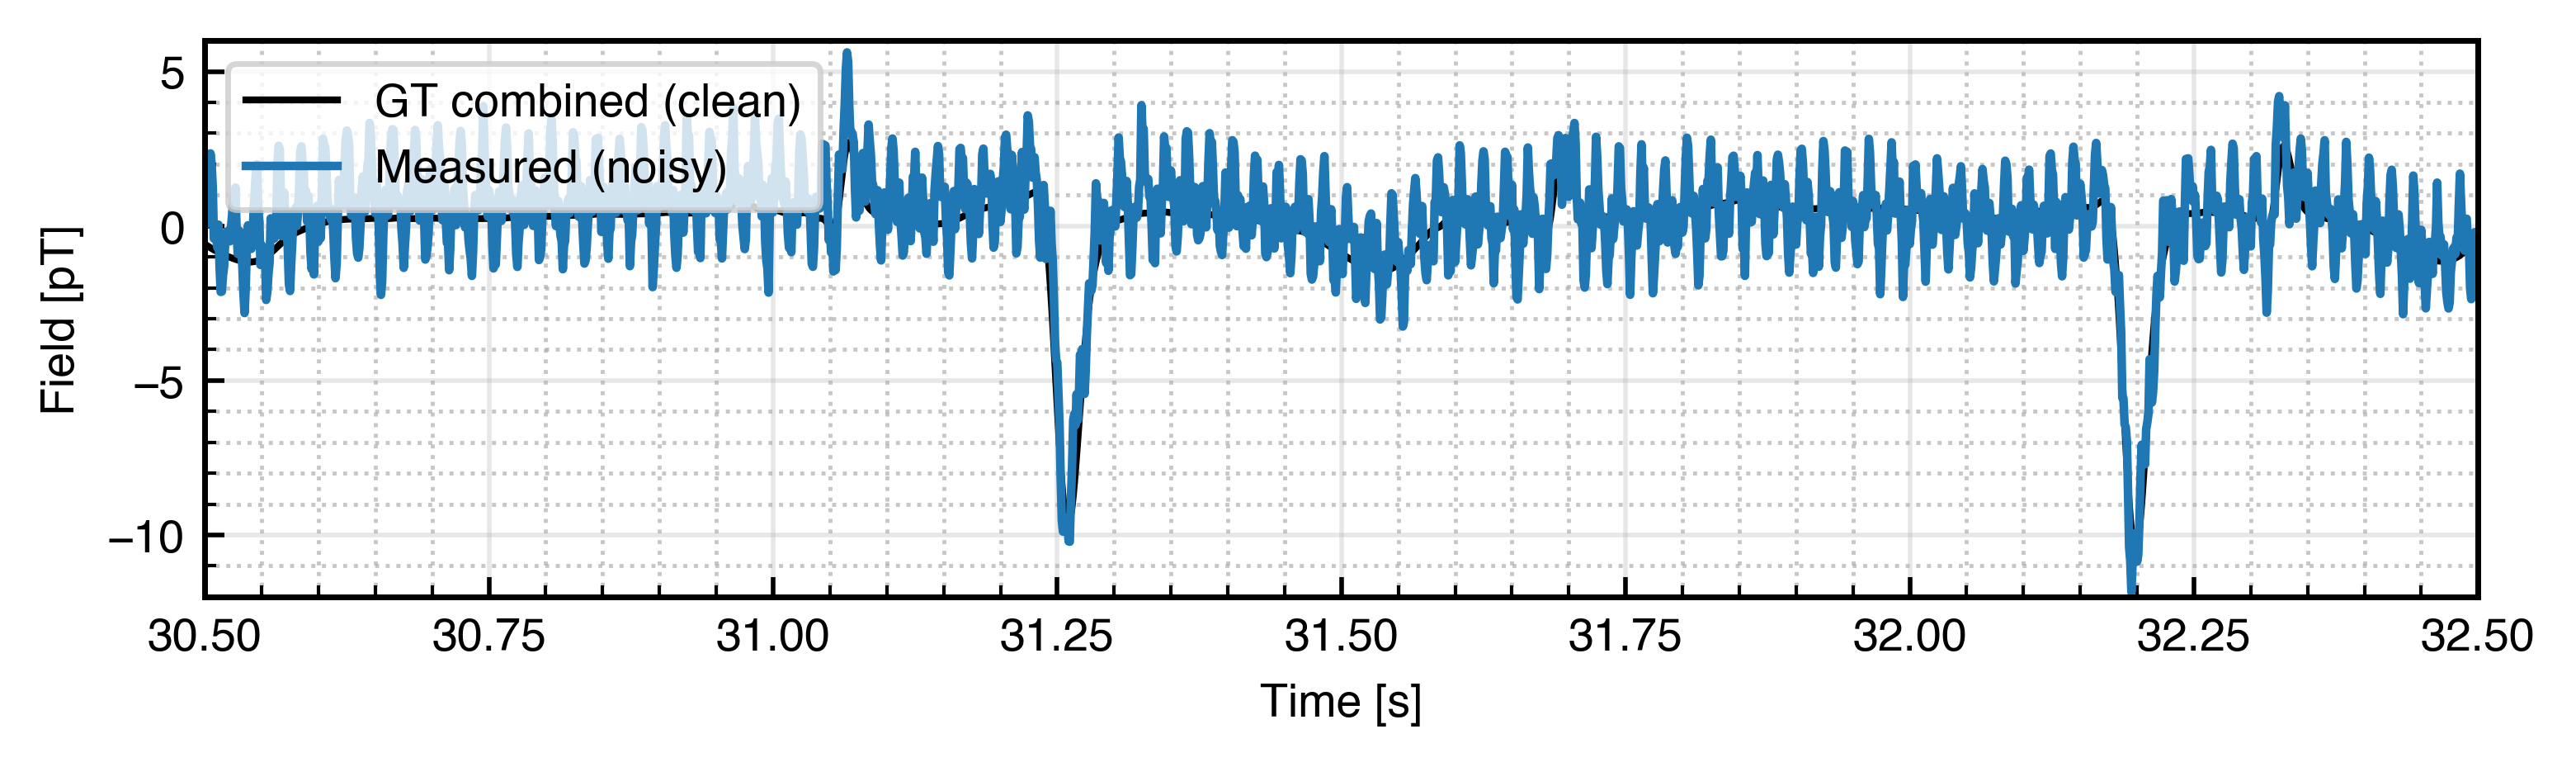

In [6]:
# Noisy measurement vs noiseless combined field
gt_measured = field_measured[:, axis_mask == 1]  # (T, C) [pT]

print(f"Measured peak: {np.nanmax(np.abs(gt_measured)):.1f} pT")

fig = plot_single_channel(
    gt_clean,
    [gt_measured],
    channel=10,
    time=time,
    xlim=(30.5, 32.5),
    method_labels=['Measured (noisy)'],
    gt_label='GT combined (clean)',
    ylabel='Field [pT]',
)

## Preprocess + Ground Truth Reference

In [7]:
from fmcg.signal.filtering import downsample

N = r_sensors.shape[0]
sensor_names_list = [f"s{i:02d}" for i in range(N)]

# Convert (T, N, 3) synthetic field to sensor dict expected by preprocess()
sig_dict = {name: field_measured[:, i, :] for i, name in enumerate(sensor_names_list)}
# Real noise recording for whitening
noise_dict = {name: arr for name, arr in zip(sensor_names_list, noise_dict_raw.values())}

preprocess_params = dict(
    bandpass_low=1.0,
    bandpass_high=40.0,
    bandpass_order=4,
    whitening="PCA",
    rescale_whitening=True,
    skip_outlier_removal=True,  # all synthetic channels are valid by construction
    downsample_factor=4,        # 1000 Hz → 250 Hz (matches pipeline_config.py)
    detect_artifacts=False,
    channel_mask=axis_mask,
    sampfrom=0,
    sampto=None,
)

field_maps, _, axis_mask_pp, W_n, fs_pp, time_pp, *_ = preprocess(sig_dict, noise_dict, fs, preprocess_params, time=time, r_sensors=r_sensors)

n_valid = int(axis_mask_pp.sum())

print(f"Valid channels: {n_valid} / {axis_mask_pp.size}")
print(f"Preprocessed: {field_maps.shape[0]} samples at {fs_pp} Hz")

# --- GT reference fields: reconstruct from decimated dipoles via ForwardModel ---
(m_true_dec, r_true_dec), _ = downsample([m_true, r_true], fs=int(fs), fs_target=int(fs_pp))
T_pp = field_maps.shape[0]
m_true_dec, r_true_dec = m_true_dec[:T_pp], r_true_dec[:T_pp]  # align ±1 sample

fm_gt = ForwardModel(r_sensors, device='cpu')
gt_fetal_phys = fm_gt.forward_linear(
    r_true_dec[:, [0], :], m_true_dec[:, [0], :], as_numpy=True
)[:, axis_mask_pp == 1]
gt_maternal_phys = fm_gt.forward_linear(
    r_true_dec[:, [1], :], m_true_dec[:, [1], :], as_numpy=True
)[:, axis_mask_pp == 1]

print(f"GT fetal peak:    {np.nanmax(np.abs(gt_fetal_phys)):.2f} pT")
print(f"GT maternal peak: {np.nanmax(np.abs(gt_maternal_phys)):.2f} pT")

Valid channels: 33 / 48
Preprocessed: 15000 samples at 250 Hz
GT fetal peak:    4.96 pT
GT maternal peak: 16.32 pT


## Annotate ICA Components

ICA- and spatial filtering–based processing requires manual intervention in the form of ICA component labeling. For (splined) Independent Component Subtraction (ICS), each component must be carefully annotated as fetal, maternal, or noise. In spatial filtering approaches, at least one template component containing either the fetal signal (for enhancement methods) or the maternal signal (for suppression methods) must be identified.

In this example, we use an enhancing LMMSE Wiener filter together with splined ICS. Due to the construction of this synthetic dataset, the fetal component can be identified by its higher heart rate compared to the maternal component.

In [8]:
%matplotlib widget
plt.close('all')

labeler = ICAComponentLabeler.from_filtered_signal(
    signal=field_maps[:, axis_mask_pp == 1],
    fs=fs_pp,
    time=time_pp,
    axis_mask=axis_mask_pp,
    n_components=10,
    seed=42,
    xlim=[10, 20],
    canvas_size=('300px', '30px'),
    fig_size=(8, 2),
    base_path="./_ica_annotation"
)
labeler.show()

Applying ICA...
Data shape before ICA: (15000, 33)
Extracted 10 ICA components
Launching ICA Component Labeler GUI...


In [9]:
plt.close('all')
%matplotlib inline

annotation = labeler.get_results()
sources   = annotation['sources']   # (T, n_comp) ICA source time-courses
ica       = annotation['ica']       # fitted FastICA object
fetals    = np.where(np.array(annotation['component_labels']) == 'Fetal')[0]
maternals = np.where(np.array(annotation['component_labels']) == 'Maternal')[0]

print(f"Fetal components:    {fetals}")
print(f"Maternal components: {maternals}")

Fetal components:    [5 6 9]
Maternal components: [1 2 8]


## Splined ICS Reconstruction

Splined Independent Component Subtraction: reconstruct and subtract spline-smoothed
maternal components from the data. The remainder is the fetal estimate.

In [10]:
# Splined ICS: reconstruct maternal components (splined), subtract from data → fetal
# comp=maternals: components to reconstruct and subtract
# keep_sources=True: keep selected components (zero others)
# field_subtract=True: return (data - reconstruction, reconstruction) = (fetal, maternal)
# spline=True: smooth the maternal source time-courses before back-projection
field_fetal_ICS_w, field_maternal_ICS_w = ics(
    ica,
    field_maps[:, axis_mask_pp == 1],  # (T, C) whitened valid channels
    sources,
    maternals,
    fs_pp,
    keep_sources=True,
    field_subtract=True,
    spline=True,
)
# Outputs are in the whitened domain (T, C)

## Spatial Filtering (LMMSE)
This reconstructs the fetal signal by using the previously annotated fetal reference to detect peaks and averaging them to form a spatial template.


In [11]:
sf = SpatialFilter(
    method='lmmse',
    fs=fs_pp,
    enhance={'sources': sources, 'comps': fetals},
    axis_mask=axis_mask_pp,
)
field_fetal_LMMSE_w = sf.apply(field_maps[:, axis_mask_pp == 1])  # (T, C) whitened
# LMMSE only produces fetal field (single-entity spatial filter)

## Forward Model

Fit a two-dipole forward model (fetal + maternal) to the whitened data via gradient
descent using the LAMB optimizer and cross-correlation penalty.

Iterations: 100%|██████████| 550/550 [00:08<00:00, 65.09it/s, Best Loss=0.00528]


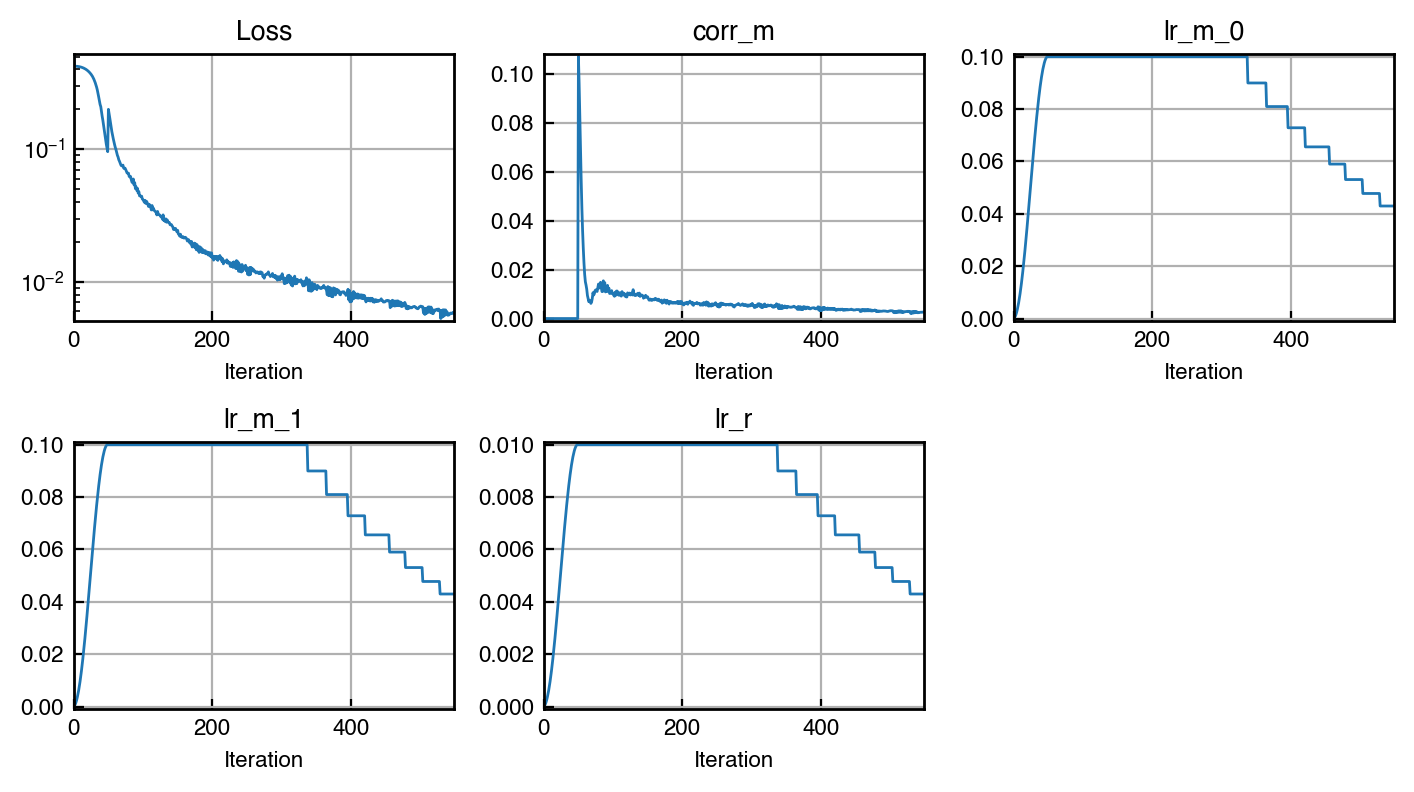


Fitted fetal position (mean): [-0.008 -0.091  0.008] m
True  fetal position:         [-0.006 -0.08   0.005] m
Fitted maternal position (mean): [ 0.066 -0.091  0.375] m
True  maternal position:         [ 0.023 -0.047  0.36 ] m


In [12]:
T = field_maps.shape[0]
field_tensor = torch.tensor(field_maps, dtype=torch.float32, device="cuda:0")

R_BNDS = np.array([
    [(-0.3, 0.3), (-0.3, -0.005), (-0.3, 0.3)],  # fetal bounds
    [(-0.3, 0.3), (-0.3, -0.005), (0.1, 0.6)],    # maternal bounds
])

# Position basis: sigmoid_time_constant (static positions with smooth transitions)
r_basis_args = {"basis": "sigmoid_time_constant", "n_time": T, "bnds": R_BNDS}

# Repeat initial position guess across all time steps
r_init_tensor = torch.tensor(
    np.repeat([[[0, -0.02, 0.0], [0, -0.05, 0.2]]], T, axis=0),  # (T, 2, 3)
    dtype=torch.float32, device="cuda:0",
)

solver = InverseSolver(
    r_sensors=r_sensors,
    method="lamb",
    num_dipoles=2,
    axis_mask=axis_mask_pp,
    scaling=dict(m=[1e0, 1e0]),
    basis=dict(r=r_basis_args),
    bnds=dict(r=R_BNDS),
    whitening_matrix=W_n,
    device="cuda:0",
    verbose=True,
)

initial_params, field_scaled = solver.initialize_parameters(
    r=r_init_tensor,
    field_true=field_tensor,
    field_scaling=1e0,
    method="pseudo_inv_regularized",
    rcond=1e0,
    determine_scaling=True,
    update_m_scaling=True,
)

m_hat, r_hat = solver.solve(
    field_scaled,
    initial_params,
    lr={
        "niter": 500,
        "warmup": 50,
        "lr_groups": [1e-1, 1e-1, 1e-2],   # [lr_m_0, lr_m_1, lr_r]
        "patience_groups": [20],
        "early_stopping_patience": 50,
        "early_stopping_threshold": 1e-8,
        "min_iter": 300,
        "cooldown_iterations": 10,
    },
    loss_params={
        # Cross-correlation penalty
        "corr_m": {"weight": 5e-1, "lag": 25, "window": 2500, "step": 1},
    },
    plot=True,
    early_stop=True,
)
# m_hat: (T, 2, 3) fitted moments [µA·m²],  r_hat: (T, 2, 3) fitted positions [m]
print(f"\nFitted fetal position (mean): {r_hat[:, 0, :].mean(axis=0).round(3)} m")
print(f"True  fetal position:         {r_true_dec[:, 0, :].mean(axis=0).round(3)} m")
print(f"Fitted maternal position (mean): {r_hat[:, 1, :].mean(axis=0).round(3)} m")
print(f"True  maternal position:         {r_true_dec[:, 1, :].mean(axis=0).round(3)} m")

## Convert Reconstructions to Physical Domain

All evaluation is done in physical [pT]. ICA/SF outputs are natively whitened → unwhiten.
The forward model output is already physical (field reconstructed from fitted dipoles).

In [14]:
# Domain helper
def to_physical(f_whitened):
    return np.linalg.solve(W_n, f_whitened.T).T

# ICA/SF: whitened → physical
field_fetal_ICS_phys    = to_physical(field_fetal_ICS_w)
field_maternal_ICS_phys = to_physical(field_maternal_ICS_w)
field_fetal_LMMSE_phys  = to_physical(field_fetal_LMMSE_w)

# Forward Model: reconstruct fetal + maternal fields from fitted dipoles
fm = ForwardModel(r_sensors, device='cpu')

field_fetal_FM_phys_3d = fm.forward_linear(r_hat[:, [0], :], m_hat[:, [0], :], as_numpy=True)
field_fetal_FM_phys = field_fetal_FM_phys_3d[:, axis_mask_pp == 1]   # (T, C)

field_maternal_FM_phys_3d = fm.forward_linear(r_hat[:, [1], :], m_hat[:, [1], :], as_numpy=True)
field_maternal_FM_phys = field_maternal_FM_phys_3d[:, axis_mask_pp == 1]   # (T, C)


## Visual Comparison

Single-channel comparison of fetal field reconstructions vs GT in the field domain. An exemplary channel is shown.

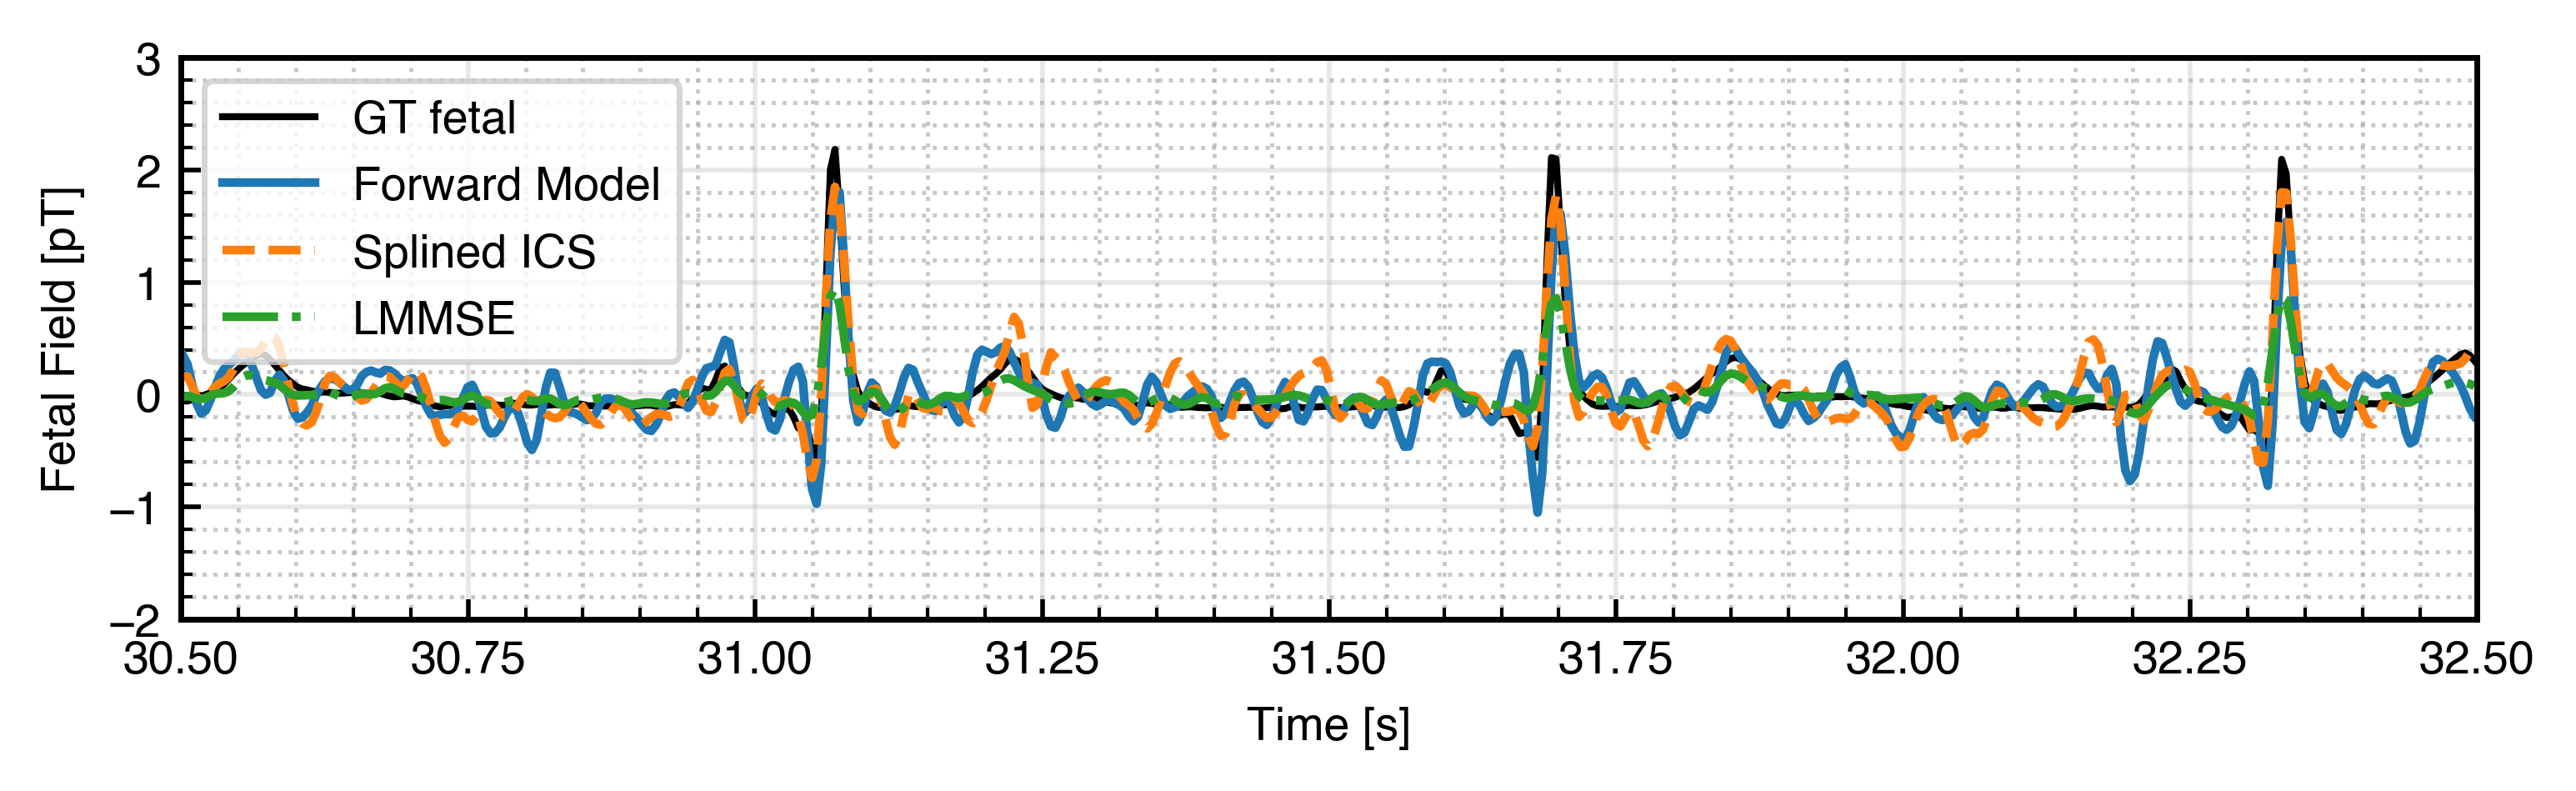

In [15]:
fig = plot_single_channel(
    gt_fetal_phys,
    [field_fetal_FM_phys, field_fetal_ICS_phys, field_fetal_LMMSE_phys],
    channel=10,
    time=time_pp,
    xlim=(30.5, 32.5),
    method_labels=['Forward Model', 'Splined ICS', 'LMMSE'],
    gt_label='GT fetal',
    ylabel='Fetal Field [pT]',
)

## Field Domain Metrics

Evaluate all three methods in physical [pT] for both fetal and maternal source fields.

In [18]:
methods = {
    "Splined ICS":   (field_fetal_ICS_phys,  field_maternal_ICS_phys),
    "LMMSE":         (field_fetal_LMMSE_phys, None),
    "Forward Model": (field_fetal_FM_phys,    field_maternal_FM_phys),
}

rows = []
for method_name, (pred_f, pred_m) in methods.items():
    row = {"Method": method_name}
    row.update(compute_named_field_metrics("fetal", pred_f, gt_fetal_phys))
    if pred_m is not None:
        row.update(compute_named_field_metrics("maternal", pred_m, gt_maternal_phys))
    rows.append(row)

df_field = pd.DataFrame(rows).set_index("Method")

display_cols = [
    "field_fetal_rel_error_peak_pct", "field_fetal_r2",
    "field_maternal_rel_error_peak_pct", "field_maternal_r2",
]
display_cols = [c for c in display_cols if c in df_field.columns]
df_field[display_cols].rename(columns=lambda c: c.replace("field_", "").replace("_", " ").title()).round(3)

,Fetal Rel Error Peak Pct,Fetal R2,Maternal Rel Error Peak Pct,Maternal R2
Method,,,,
Splined ICS,4.640,0.442,1.663,0.956
LMMSE,3.509,0.681,NaN,NaN
Forward Model,2.572,0.829,1.879,0.943


## Dipole Domain Metrics (Forward Model Only)

Compare fitted dipole moments and positions against ground truth. These metrics are
only available for the forward model approach.

In [ ]:
dipole_rows = []
for idx, entity in enumerate(["fetal", "maternal"]):
    m_pred = m_hat[:, idx, :]        # (T, 3) [µA·m²]
    m_ref  = m_true_dec[:, idx, :]   # (T, 3) [µA·m²] 
    r_pred = r_hat[:, idx, :]        # (T, 3) [m]
    r_ref  = r_true_dec[:, idx, :]   # (T, 3) [m] 

    # Moment metrics
    m_diff = m_pred - m_ref
    m_mae_uAm2 = np.nanmean(np.abs(m_diff))
    m_rmse_uAm2 = np.sqrt(np.nanmean(m_diff**2))
    m_ref_peak = np.nanmax(np.abs(m_ref))
    m_nrmse_pct = 100 * m_rmse_uAm2 / m_ref_peak if m_ref_peak > 0 else np.nan

    # Moment scale fit (best scalar s: minimize ||s*pred - ref||²)
    m_pred_flat = m_pred.flatten()
    m_ref_flat = m_ref.flatten()
    m_scale = float(m_pred_flat @ m_ref_flat) / float(m_pred_flat @ m_pred_flat) if np.any(m_pred_flat) else np.nan
    m_scaled_rmse = np.sqrt(np.nanmean((m_scale * m_pred - m_ref)**2))
    m_nrmse_scaled_pct = 100 * m_scaled_rmse / m_ref_peak if m_ref_peak > 0 else np.nan

    # Position metrics
    r_diff = r_pred - r_ref
    r_mae_cm = np.nanmean(np.abs(r_diff)) * 100
    r_rmse_cm = np.sqrt(np.nanmean(r_diff**2)) * 100

    dipole_rows.append({
        "Entity": entity.capitalize(),
        "Moment NRMSE [%]": m_nrmse_pct,
        "Position RMSE [cm]": r_rmse_cm,
    })

df_dipole = pd.DataFrame(dipole_rows).set_index("Entity")
df_dipole.round(3)

,Moment NRMSE [%],Position RMSE [cm]
Entity,,
Fetal,4.708,0.662
Maternal,3.974,3.663
